<a href="https://colab.research.google.com/github/Tejaswimadastu/Deep_Learning/blob/main/IMDB_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from tensorflow.keras.datasets import imdb
import numpy as np
import pandas as pd

In [2]:
(x_train, y_train), (x_test, y_test) = imdb.load_data()

print("Training Reviews :", len(x_train))
print("Testing Reviews  :", len(x_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Reviews : 25000
Testing Reviews  : 25000


In [3]:
total_reviews = len(x_train) + len(x_test)

print("Total Reviews:", total_reviews)

Total Reviews: 50000


# Positive reviews

In [4]:
positive_reviews = np.sum(y_train) + np.sum(y_test)

print("Positive Reviews:", positive_reviews)

Positive Reviews: 25000


# Negative Reviews

In [5]:
negative_reviews = total_reviews - positive_reviews

print("Negative Reviews:", negative_reviews)

Negative Reviews: 25000


Average review length

In [6]:
all_reviews = list(x_train) + list(x_test)

review_lengths = [len(review) for review in all_reviews]

average_length = np.mean(review_lengths)

print("Average Review Length:", average_length)

Average Review Length: 234.75892


Longest Review

In [7]:
longest_review = max(review_lengths)

print("Longest Review Length:", longest_review)

Longest Review Length: 2494


Shortest Review

In [8]:
shortest_review = min(review_lengths)

print("Shortest Review Length:", shortest_review)

Shortest Review Length: 7


Complete Analysis Table

In [9]:
analysis = pd.DataFrame({
    "Metric":[
        "Total Reviews",
        "Positive Reviews",
        "Negative Reviews",
        "Average Review Length",
        "Longest Review Length",
        "Shortest Review Length"
    ],
    "Value":[
        total_reviews,
        positive_reviews,
        negative_reviews,
        round(average_length,2),
        longest_review,
        shortest_review
    ]
})

print(analysis)

                   Metric     Value
0           Total Reviews  50000.00
1        Positive Reviews  25000.00
2        Negative Reviews  25000.00
3   Average Review Length    234.76
4   Longest Review Length   2494.00
5  Shortest Review Length      7.00


Class Distribution

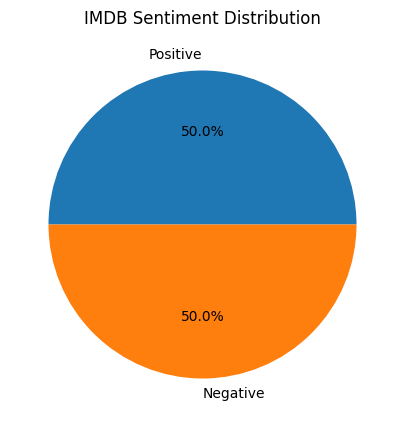

In [10]:
import matplotlib.pyplot as plt

labels = ["Positive", "Negative"]
counts = [positive_reviews, negative_reviews]

plt.figure(figsize=(5,5))
plt.pie(counts, labels=labels, autopct="%1.1f%%")
plt.title("IMDB Sentiment Distribution")
plt.show()

Visualize Review Length

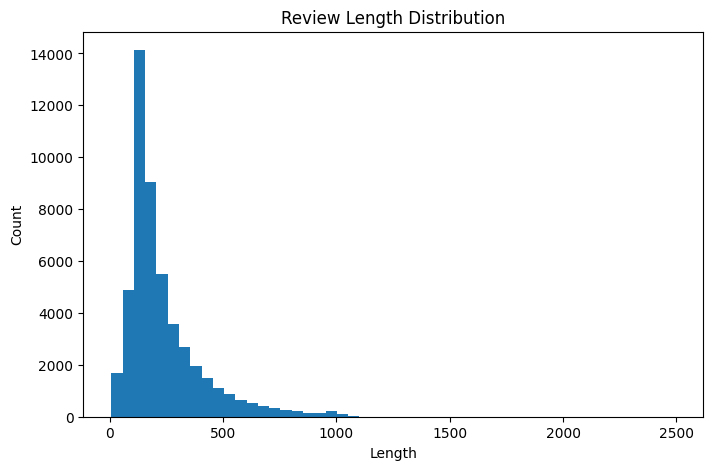

In [11]:
plt.figure(figsize=(8,5))
plt.hist(review_lengths, bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()

In [12]:
import re
import string
import nltk

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from nltk.corpus import stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [13]:
vocab_size = 10000

(x_train, y_train), (x_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

In [14]:
word_index = imdb.get_word_index()

reverse_word_index = {
    value + 3: key
    for key, value in word_index.items()
}

reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [15]:
def decode_review(encoded_review):
    return " ".join(
        reverse_word_index.get(i, "?")
        for i in encoded_review
    )

In [16]:
def lowercase_text(text):
    return text.lower()

In [17]:
def remove_html(text):
    return re.sub(
        r'<.*?>',
        '',
        text
    )

In [18]:
def remove_punctuation(text):
    return text.translate(
        str.maketrans(
            '',
            '',
            string.punctuation
        )
    )

In [19]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()

    filtered_words = [
        word
        for word in words
        if word not in stop_words
    ]

    return " ".join(filtered_words)

In [20]:
def preprocess_text(text):

    text = lowercase_text(text)

    text = remove_html(text)

    text = remove_punctuation(text)

    text = remove_stopwords(text)

    return text

In [21]:
decoded_reviews = [
    decode_review(review)
    for review in x_train[:5000]
]

clean_reviews = [
    preprocess_text(review)
    for review in decoded_reviews
]

In [22]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(
    clean_reviews
)

In [23]:
sequences = tokenizer.texts_to_sequences(
    clean_reviews
)

In [26]:
max_length = 200
padded_sequences = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

In [27]:
print(padded_sequences.shape)

(5000, 200)


In [28]:
decoded_reviews = [
    decode_review(review)
    for review in x_train[:5000]
]

clean_reviews = [
    preprocess_text(review)
    for review in decoded_reviews
]

tokenizer = Tokenizer(
    num_words=10000,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(
    clean_reviews
)

sequences = tokenizer.texts_to_sequences(
    clean_reviews
)

padded_sequences = pad_sequences(
    sequences,
    maxlen=200,
    padding='post',
    truncating='post'
)

print(padded_sequences.shape)

(5000, 200)


# Task 3: Build and Train a SimpleRNN Model

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from sklearn.model_selection import train_test_split

In [30]:
padded_sequences
y_train
X_train, X_test, y_train_split, y_test_split = train_test_split(
    padded_sequences,
    y_train[:5000],
    test_size=0.2,
    random_state=42
)

In [31]:
simple_rnn_model = Sequential([
    Embedding(
        input_dim=10000,
        output_dim=32,
        input_length=200
    ),

    SimpleRNN(
        32
    ),

    Dense(
        16,
        activation='relu'
    ),

    Dense(
        1,
        activation='sigmoid'
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [32]:
simple_rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [33]:
simple_rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [34]:
history_rnn = simple_rnn_model.fit(
    X_train,
    y_train_split,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test_split),
    verbose=1
)

Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.4877 - loss: 0.6960 - val_accuracy: 0.4920 - val_loss: 0.6932
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.5847 - loss: 0.6777 - val_accuracy: 0.4930 - val_loss: 0.6951
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.5943 - loss: 0.6645 - val_accuracy: 0.5190 - val_loss: 0.6938
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.6070 - loss: 0.6425 - val_accuracy: 0.4880 - val_loss: 0.7017
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.6277 - loss: 0.6052 - val_accuracy: 0.4930 - val_loss: 0.7039


In [35]:
loss_rnn, accuracy_rnn = simple_rnn_model.evaluate(
    X_test,
    y_test_split,
    verbose=0
)

print("SimpleRNN Accuracy:", accuracy_rnn)
print("SimpleRNN Loss:", loss_rnn)

SimpleRNN Accuracy: 0.49300000071525574
SimpleRNN Loss: 0.7039398550987244


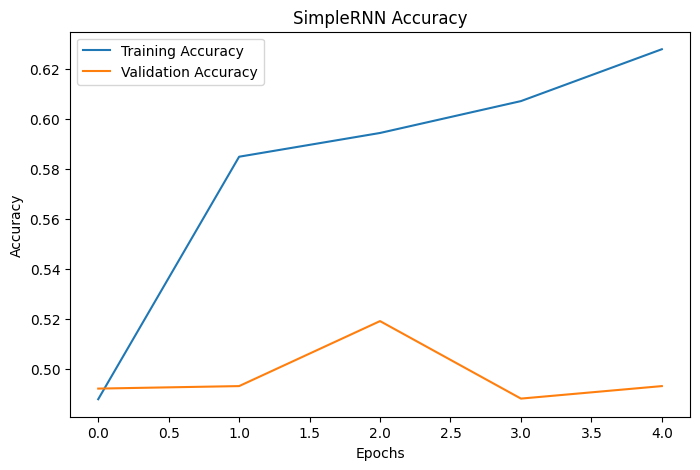

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_rnn.history['accuracy'])
plt.plot(history_rnn.history['val_accuracy'])

plt.title("SimpleRNN Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend([
    "Training Accuracy",
    "Validation Accuracy"
])

plt.show()

In [37]:
def predict_sentiment(model, review):

    seq = tokenizer.texts_to_sequences([review])

    padded = pad_sequences(
        seq,
        maxlen=200
    )

    prediction = model.predict(
        padded,
        verbose=0
    )[0][0]

    if prediction >= 0.5:
        return "Positive", prediction
    else:
        return "Negative", prediction

In [38]:
review = "This movie was absolutely fantastic"

result, score = predict_sentiment(
    simple_rnn_model,
    review
)

print("Prediction:", result)
print("Score:", score)

Prediction: Negative
Score: 0.47098348


In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

In [40]:
lstm_model = Sequential([
    Embedding(
        input_dim=10000,
        output_dim=32,
        input_length=200
    ),

    LSTM(32),

    Dense(
        16,
        activation='relu'
    ),

    Dense(
        1,
        activation='sigmoid'
    )
])

In [41]:
lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [42]:
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [43]:
history_lstm = lstm_model.fit(
    X_train,
    y_train_split,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test_split),
    verbose=1
)

Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 107ms/step - accuracy: 0.5042 - loss: 0.6931 - val_accuracy: 0.4990 - val_loss: 0.6928
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 0.5173 - loss: 0.6899 - val_accuracy: 0.5220 - val_loss: 0.7076
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - accuracy: 0.5550 - loss: 0.6656 - val_accuracy: 0.5060 - val_loss: 0.6850
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - accuracy: 0.5695 - loss: 0.6414 - val_accuracy: 0.5070 - val_loss: 0.6859
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - accuracy: 0.5880 - loss: 0.6257 - val_accuracy: 0.5380 - val_loss: 0.6884


In [44]:
loss_lstm, accuracy_lstm = lstm_model.evaluate(
    X_test,
    y_test_split,
    verbose=0
)

print("LSTM Accuracy :", accuracy_lstm)
print("LSTM Loss :", loss_lstm)

LSTM Accuracy : 0.5379999876022339
LSTM Loss : 0.6883533596992493


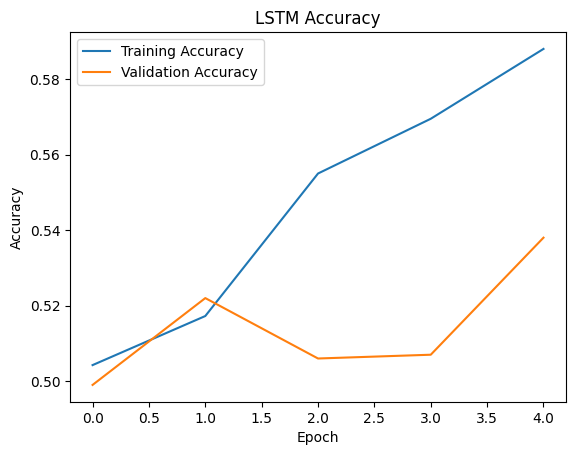

In [45]:
import matplotlib.pyplot as plt

plt.plot(history_lstm.history['accuracy'])
plt.plot(history_lstm.history['val_accuracy'])

plt.title("LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Training Accuracy",
    "Validation Accuracy"
])

plt.show()

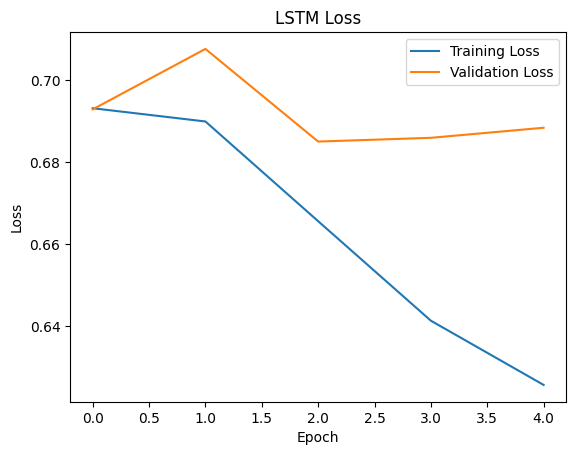

In [46]:
plt.plot(history_lstm.history['loss'])
plt.plot(history_lstm.history['val_loss'])

plt.title("LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Training Loss",
    "Validation Loss"
])

plt.show()

In [47]:
review = "This movie was amazing and fantastic"

result, score = predict_sentiment(
    lstm_model,
    review
)

print("Prediction :", result)
print("Confidence :", score)

Prediction : Positive
Confidence : 0.50146776


In [48]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense

In [49]:
gru_model = Sequential([
    Embedding(
        input_dim=10000,
        output_dim=32,
        input_length=200
    ),

    GRU(32),

    Dense(
        16,
        activation='relu'
    ),

    Dense(
        1,
        activation='sigmoid'
    )
])

In [50]:
gru_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [51]:
gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [52]:
history_gru = gru_model.fit(
    X_train,
    y_train_split,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test_split),
    verbose=1
)

Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 131ms/step - accuracy: 0.4820 - loss: 0.6937 - val_accuracy: 0.5340 - val_loss: 0.6924
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 129ms/step - accuracy: 0.5098 - loss: 0.6926 - val_accuracy: 0.4970 - val_loss: 0.6928
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - accuracy: 0.5525 - loss: 0.6867 - val_accuracy: 0.5170 - val_loss: 0.6935
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 135ms/step - accuracy: 0.5648 - loss: 0.6455 - val_accuracy: 0.4970 - val_loss: 0.7850
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 120ms/step - accuracy: 0.5652 - loss: 0.6041 - val_accuracy: 0.5160 - val_loss: 0.7299


In [53]:
loss_gru, accuracy_gru = gru_model.evaluate(
    X_test,
    y_test_split,
    verbose=0
)

print("GRU Accuracy :", accuracy_gru)
print("GRU Loss :", loss_gru)

GRU Accuracy : 0.515999972820282
GRU Loss : 0.7298611998558044


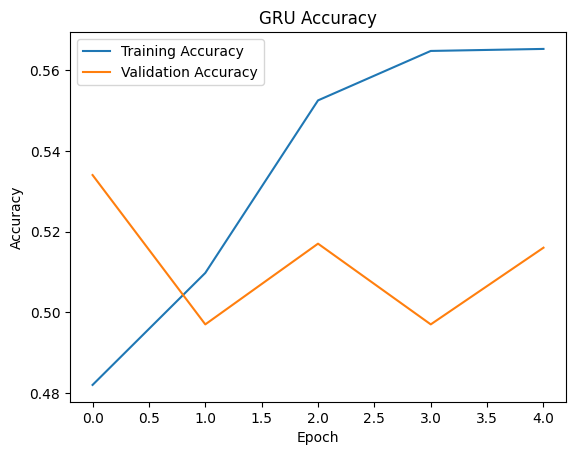

In [54]:
import matplotlib.pyplot as plt

plt.plot(history_gru.history['accuracy'])
plt.plot(history_gru.history['val_accuracy'])

plt.title("GRU Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Training Accuracy",
    "Validation Accuracy"
])

plt.show()

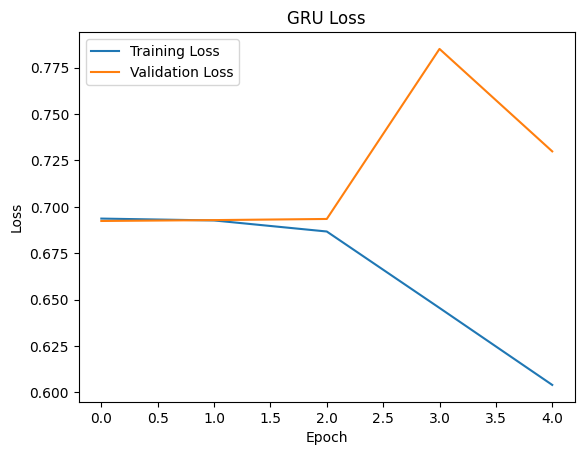

In [55]:
plt.plot(history_gru.history['loss'])
plt.plot(history_gru.history['val_loss'])

plt.title("GRU Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Training Loss",
    "Validation Loss"
])

plt.show()

In [56]:
review = "This movie was amazing and fantastic"

result, score = predict_sentiment(
    gru_model,
    review
)

print("Prediction :", result)
print("Confidence :", score)

Prediction : Positive
Confidence : 0.8674984


In [57]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import pandas as pd
import time

In [58]:
start = time.time()

history_rnn = simple_rnn_model.fit(
    X_train,
    y_train_split,
    epochs=5,
    validation_data=(X_test, y_test_split),
    verbose=1
)

rnn_time = time.time() - start

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.6030 - loss: 0.6054 - val_accuracy: 0.4890 - val_loss: 0.7333
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - accuracy: 0.6118 - loss: 0.5906 - val_accuracy: 0.4620 - val_loss: 0.8506
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.6237 - loss: 0.5841 - val_accuracy: 0.4870 - val_loss: 0.7292
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.5895 - loss: 0.5960 - val_accuracy: 0.4970 - val_loss: 0.7391
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.6202 - loss: 0.5697 - val_accuracy: 0.5280 - val_loss: 0.7380


In [59]:
start = time.time()

history_lstm = lstm_model.fit(
    X_train,
    y_train_split,
    epochs=5,
    validation_data=(X_test, y_test_split),
    verbose=1
)

lstm_time = time.time() - start

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - accuracy: 0.5792 - loss: 0.6001 - val_accuracy: 0.5040 - val_loss: 0.7456
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.5690 - loss: 0.5982 - val_accuracy: 0.5400 - val_loss: 0.7143
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step - accuracy: 0.5803 - loss: 0.5891 - val_accuracy: 0.5230 - val_loss: 0.7765
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step - accuracy: 0.5828 - loss: 0.5838 - val_accuracy: 0.5430 - val_loss: 0.7490
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - accuracy: 0.5710 - loss: 0.6889 - val_accuracy: 0.5200 - val_loss: 0.6863


In [60]:
rnn_pred = (simple_rnn_model.predict(X_test) > 0.5).astype(int)

lstm_pred = (lstm_model.predict(X_test) > 0.5).astype(int)

gru_pred = (gru_model.predict(X_test) > 0.5).astype(int)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


In [61]:
rnn_accuracy = accuracy_score(y_test_split, rnn_pred)
rnn_precision = precision_score(y_test_split, rnn_pred)
rnn_recall = recall_score(y_test_split, rnn_pred)
rnn_f1 = f1_score(y_test_split, rnn_pred)

In [62]:
lstm_accuracy = accuracy_score(y_test_split, lstm_pred)
lstm_precision = precision_score(y_test_split, lstm_pred)
lstm_recall = recall_score(y_test_split, lstm_pred)
lstm_f1 = f1_score(y_test_split, lstm_pred)

In [63]:
gru_accuracy = accuracy_score(y_test_split, gru_pred)
gru_precision = precision_score(y_test_split, gru_pred)
gru_recall = recall_score(y_test_split, gru_pred)
gru_f1 = f1_score(y_test_split, gru_pred)

In [64]:
rnn_val_acc = history_rnn.history['val_accuracy'][-1]
rnn_val_loss = history_rnn.history['val_loss'][-1]

lstm_val_acc = history_lstm.history['val_accuracy'][-1]
lstm_val_loss = history_lstm.history['val_loss'][-1]

gru_val_acc = history_gru.history['val_accuracy'][-1]
gru_val_loss = history_gru.history['val_loss'][-1]

In [65]:
rnn_params = simple_rnn_model.count_params()
lstm_params = lstm_model.count_params()
gru_params = gru_model.count_params()

In [67]:
import time

start = time.time()

history_gru = gru_model.fit(
    X_train,
    y_train_split,
    epochs=5,
    validation_data=(X_test, y_test_split),
    verbose=1
)

gru_time = time.time() - start

print("GRU Training Time:", gru_time)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 133ms/step - accuracy: 0.5688 - loss: 0.5949 - val_accuracy: 0.5400 - val_loss: 0.7375
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 101ms/step - accuracy: 0.5785 - loss: 0.5925 - val_accuracy: 0.5060 - val_loss: 0.7331
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 106ms/step - accuracy: 0.6217 - loss: 0.5733 - val_accuracy: 0.7240 - val_loss: 0.6147
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 105ms/step - accuracy: 0.8535 - loss: 0.3584 - val_accuracy: 0.7670 - val_loss: 0.5348
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 104ms/step - accuracy: 0.9460 - loss: 0.1645 - val_accuracy: 0.7840 - val_loss: 0.6141
GRU Training Time: 68.989422082901


In [68]:
comparison_df = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Training Time (sec)",
        "Validation Accuracy",
        "Validation Loss",
        "Parameters"
    ],

    "SimpleRNN":[
        rnn_accuracy,
        rnn_precision,
        rnn_recall,
        rnn_f1,
        rnn_time,
        rnn_val_acc,
        rnn_val_loss,
        rnn_params
    ],

    "LSTM":[
        lstm_accuracy,
        lstm_precision,
        lstm_recall,
        lstm_f1,
        lstm_time,
        lstm_val_acc,
        lstm_val_loss,
        lstm_params
    ],

    "GRU":[
        gru_accuracy,
        gru_precision,
        gru_recall,
        gru_f1,
        gru_time,
        gru_val_acc,
        gru_val_loss,
        gru_params
    ]
})

print(comparison_df)

                Metric      SimpleRNN           LSTM            GRU
0             Accuracy       0.528000       0.520000       0.516000
1            Precision       0.555970       0.685714       0.800000
2               Recall       0.560150       0.180451       0.120301
3             F1 Score       0.558052       0.285714       0.209150
4  Training Time (sec)      32.972245      48.968123      68.989422
5  Validation Accuracy       0.528000       0.520000       0.516000
6      Validation Loss       0.738007       0.686337       0.729861
7           Parameters  322625.000000  328865.000000  326881.000000


In [69]:
best_model = comparison_df.iloc[
    comparison_df[
        comparison_df["Metric"]=="Accuracy"
    ].index[0]
]

print(comparison_df)

                Metric      SimpleRNN           LSTM            GRU
0             Accuracy       0.528000       0.520000       0.516000
1            Precision       0.555970       0.685714       0.800000
2               Recall       0.560150       0.180451       0.120301
3             F1 Score       0.558052       0.285714       0.209150
4  Training Time (sec)      32.972245      48.968123      68.989422
5  Validation Accuracy       0.528000       0.520000       0.516000
6      Validation Loss       0.738007       0.686337       0.729861
7           Parameters  322625.000000  328865.000000  326881.000000


Accuracy Comparison Graph

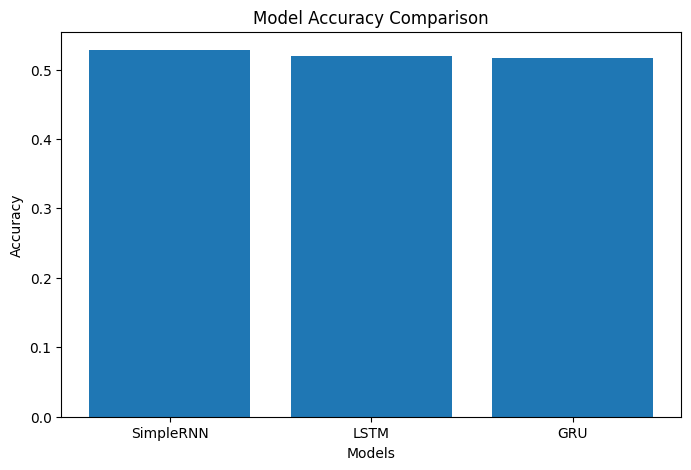

In [70]:
import matplotlib.pyplot as plt

models = ['SimpleRNN', 'LSTM', 'GRU']

accuracies = [
    rnn_accuracy,
    lstm_accuracy,
    gru_accuracy
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.title('Model Accuracy Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy')

plt.show()

Validation Accuracy Comparison Graph

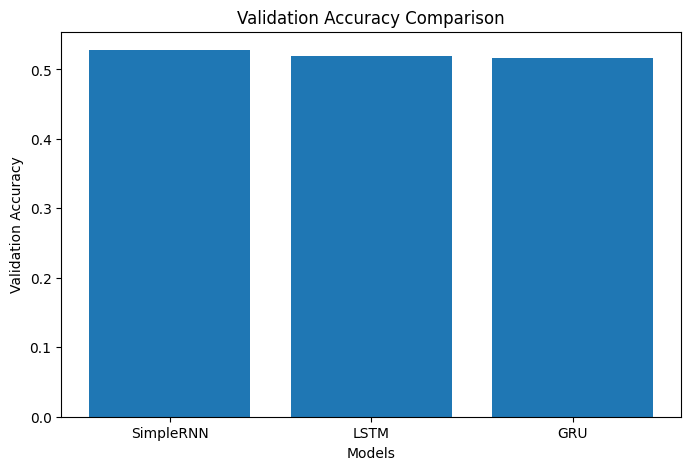

In [71]:
val_accuracies = [
    rnn_val_acc,
    lstm_val_acc,
    gru_val_acc
]

plt.figure(figsize=(8,5))

plt.bar(models, val_accuracies)

plt.title('Validation Accuracy Comparison')
plt.xlabel('Models')
plt.ylabel('Validation Accuracy')

plt.show()

Training Loss vs Validation Loss

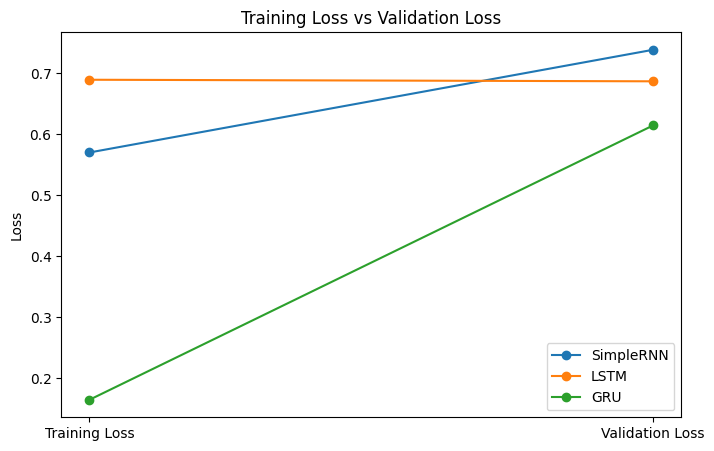

In [72]:
loss_types = ['Training Loss', 'Validation Loss']

rnn_losses = [
    history_rnn.history['loss'][-1],
    history_rnn.history['val_loss'][-1]
]

lstm_losses = [
    history_lstm.history['loss'][-1],
    history_lstm.history['val_loss'][-1]
]

gru_losses = [
    history_gru.history['loss'][-1],
    history_gru.history['val_loss'][-1]
]

x = range(len(loss_types))

plt.figure(figsize=(8,5))

plt.plot(x, rnn_losses, marker='o', label='SimpleRNN')
plt.plot(x, lstm_losses, marker='o', label='LSTM')
plt.plot(x, gru_losses, marker='o', label='GRU')

plt.xticks(x, loss_types)

plt.title('Training Loss vs Validation Loss')
plt.ylabel('Loss')

plt.legend()

plt.show()

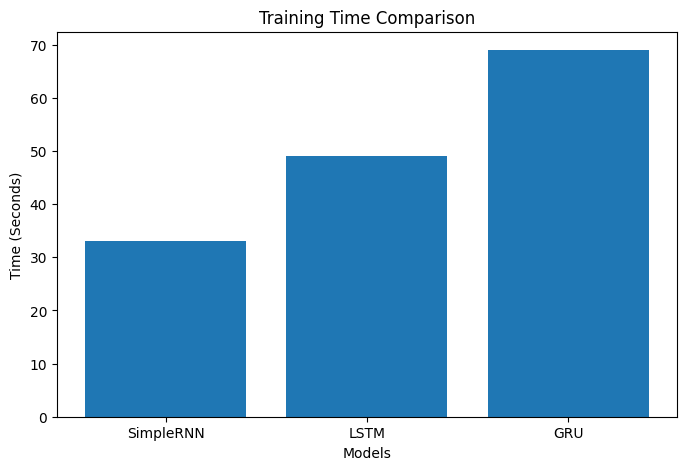

In [73]:
training_times = [
    rnn_time,
    lstm_time,
    gru_time
]

plt.figure(figsize=(8,5))

plt.bar(
    models,
    training_times
)

plt.title('Training Time Comparison')
plt.xlabel('Models')
plt.ylabel('Time (Seconds)')

plt.show()

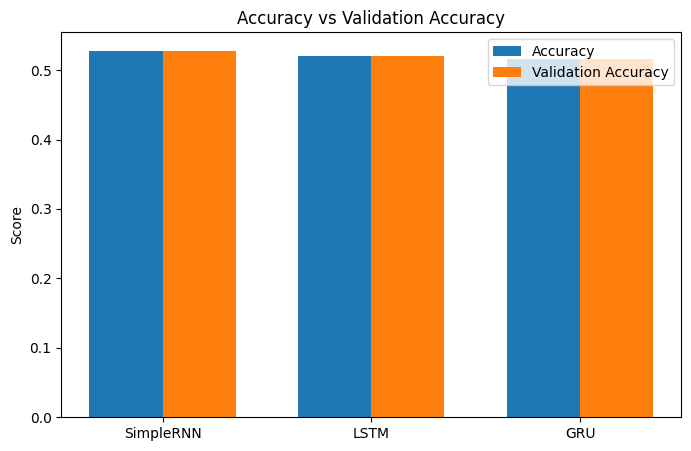

In [74]:
import numpy as np

x = np.arange(len(models))

width = 0.35

plt.figure(figsize=(8,5))

plt.bar(
    x - width/2,
    [rnn_accuracy, lstm_accuracy, gru_accuracy],
    width,
    label='Accuracy'
)

plt.bar(
    x + width/2,
    [rnn_val_acc, lstm_val_acc, gru_val_acc],
    width,
    label='Validation Accuracy'
)

plt.xticks(x, models)

plt.title('Accuracy vs Validation Accuracy')
plt.ylabel('Score')

plt.legend()

plt.show()

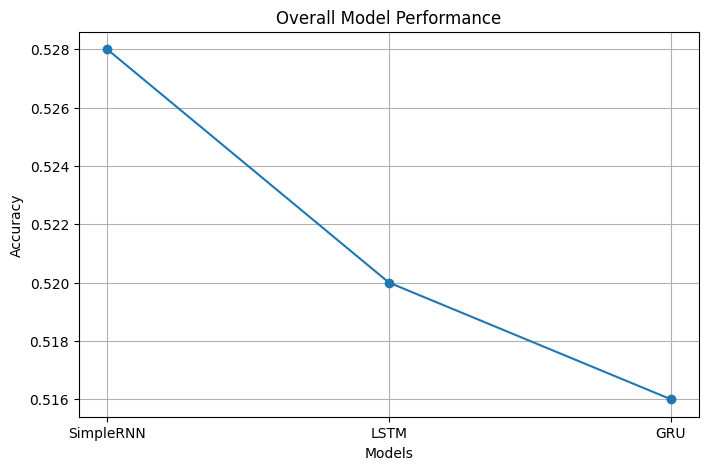

In [75]:
metrics = [
    rnn_accuracy,
    lstm_accuracy,
    gru_accuracy
]

plt.figure(figsize=(8,5))

plt.plot(
    models,
    metrics,
    marker='o'
)

plt.title('Overall Model Performance')
plt.xlabel('Models')
plt.ylabel('Accuracy')

plt.grid(True)

plt.show()

In [76]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_sentiment(model, review):

    sequence = tokenizer.texts_to_sequences([review])

    padded = pad_sequences(
        sequence,
        maxlen=200,
        padding='post',
        truncating='post'
    )

    score = model.predict(
        padded,
        verbose=0
    )[0][0]

    sentiment = "Positive" if score >= 0.5 else "Negative"

    return sentiment, float(score)

In [77]:
reviews = [
    "This movie was absolutely fantastic and I enjoyed every minute.",
    "The movie was boring and a complete waste of time.",
    "The acting was good but the story was average."
]

In [78]:
print("===== SimpleRNN Predictions =====")

for review in reviews:

    sentiment, score = predict_sentiment(
        simple_rnn_model,
        review
    )

    print("\nReview:", review)
    print("Sentiment:", sentiment)
    print("Confidence Score:", round(score,4))

===== SimpleRNN Predictions =====

Review: This movie was absolutely fantastic and I enjoyed every minute.
Sentiment: Positive
Confidence Score: 0.5178

Review: The movie was boring and a complete waste of time.
Sentiment: Negative
Confidence Score: 0.4737

Review: The acting was good but the story was average.
Sentiment: Negative
Confidence Score: 0.4881


In [79]:
print("===== LSTM Predictions =====")

for review in reviews:

    sentiment, score = predict_sentiment(
        lstm_model,
        review
    )

    print("\nReview:", review)
    print("Sentiment:", sentiment)
    print("Confidence Score:", round(score,4))

===== LSTM Predictions =====

Review: This movie was absolutely fantastic and I enjoyed every minute.
Sentiment: Negative
Confidence Score: 0.4896

Review: The movie was boring and a complete waste of time.
Sentiment: Negative
Confidence Score: 0.4896

Review: The acting was good but the story was average.
Sentiment: Negative
Confidence Score: 0.4896


In [80]:
print("===== GRU Predictions =====")

for review in reviews:

    sentiment, score = predict_sentiment(
        gru_model,
        review
    )

    print("\nReview:", review)
    print("Sentiment:", sentiment)
    print("Confidence Score:", round(score,4))

===== GRU Predictions =====

Review: This movie was absolutely fantastic and I enjoyed every minute.
Sentiment: Positive
Confidence Score: 0.6446

Review: The movie was boring and a complete waste of time.
Sentiment: Negative
Confidence Score: 0.0479

Review: The acting was good but the story was average.
Sentiment: Negative
Confidence Score: 0.209


In [81]:
import pandas as pd

results = []

for review in reviews:

    rnn_sentiment, rnn_score = predict_sentiment(
        simple_rnn_model,
        review
    )

    lstm_sentiment, lstm_score = predict_sentiment(
        lstm_model,
        review
    )

    gru_sentiment, gru_score = predict_sentiment(
        gru_model,
        review
    )

    results.append([
        review,
        rnn_sentiment,
        round(rnn_score,4),
        lstm_sentiment,
        round(lstm_score,4),
        gru_sentiment,
        round(gru_score,4)
    ])

comparison_df = pd.DataFrame(
    results,
    columns=[
        "Review",
        "RNN Sentiment",
        "RNN Score",
        "LSTM Sentiment",
        "LSTM Score",
        "GRU Sentiment",
        "GRU Score"
    ]
)

print(comparison_df)

                                              Review RNN Sentiment  RNN Score  \
0  This movie was absolutely fantastic and I enjo...      Positive     0.5178   
1  The movie was boring and a complete waste of t...      Negative     0.4737   
2     The acting was good but the story was average.      Negative     0.4881   

  LSTM Sentiment  LSTM Score GRU Sentiment  GRU Score  
0       Negative      0.4896      Positive     0.6446  
1       Negative      0.4896      Negative     0.0479  
2       Negative      0.4896      Negative     0.2090  
